# Análisis predictivo de datos - Evaluación 1

**Condiciones de entrega de la evaluación:**

- Debe entregar un archivo en formato .ipynb.
- El código debe correr correctamente cuando las celdas se ejecutan de manera secuencial.
- Debe entregar el código ya ejecutado.
- Elimine previamente todo el código que sea basura, solo entregue el código que de respuesta a lo que se le pide que haga.

Con el archivo de datos suministrado, va a crear un modelo de aprendizaje de máquina que prediga la variable **Weight**. Para escoger el modelo a utilizar se debe tener en cuenta que esta variable es **numérica** o **cuantitativa**.

Información sobre este archivo, incluido el diccionario de datos, la puede obtener en [Kaggle](https://www.kaggle.com/datasets/samruddhim/olympics-althlete-events-analysis).

## Carga y análisis exploratorio

Reporte los hallazgos en un celda de texto.

Cargue el archivo de datos, haga un breve análisis exploratorio y descarte las variables con alguna de estas condiciones:

- son claves primarias,
- tienen valores únicos,
- son redundantes con respecto a otras variables del dataset, o
- representan un riesgo de filtración de datos.

Gestione los datos duplicados y los datos nulos. En el caso de la variable **Medal**, impute a los datos nulos el valor **No medal**.

In [83]:
import pandas as pd

df = pd.read_csv("athlete_events.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  object 
 2   Sex     271116 non-null  object 
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  object 
 7   NOC     271116 non-null  object 
 8   Games   271116 non-null  object 
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  object 
 11  City    271116 non-null  object 
 12  Sport   271116 non-null  object 
 13  Event   271116 non-null  object 
 14  Medal   39783 non-null   object 
dtypes: float64(3), int64(2), object(10)
memory usage: 31.0+ MB


In [84]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [85]:
df.describe(include='object').T

,count,unique,top,freq
Name,271116,134732,Robert Tait McKenzie,58
Sex,271116,2,M,196594
Team,271116,1184,United States,17847
NOC,271116,230,USA,18853
Games,271116,51,2000 Summer,13821
Season,271116,2,Summer,222552
City,271116,42,London,22426
Sport,271116,66,Athletics,38624
Event,271116,765,Football Men's Football,5733
Medal,39783,3,Gold,13372


In [86]:
df.isnull().sum().sort_values(ascending=False) * 100 / df.shape[0]

,0
Medal,85.326207
Weight,23.191180
Height,22.193821
Age,3.494445
Sex,0.000000
ID,0.000000
Name,0.000000
Team,0.000000
NOC,0.000000
Year,0.000000


In [87]:
print('Número de registros duplicados:', df.duplicated().sum())

Número de registros duplicados: 1385


In [88]:
df.drop_duplicates(inplace=True)
df['Medal'] = df['Medal'].fillna('No medal')
df['Age'] = df.groupby('Sport')['Age'].transform(lambda x: x.fillna(x.median()))

df['Height'] = df.groupby(['Sex', 'Sport'])['Height'].transform(lambda x: x.fillna(x.median()))
df['Weight'] = df.groupby(['Sex', 'Sport'])['Weight'].transform(lambda x: x.fillna(x.median()))

# Se rellenan los valores restantes con la mediana general
df['Height'].fillna(df['Height'].median(), inplace=True)
df['Weight'].fillna(df['Weight'].median(), inplace=True)

print("Despues de deshacernos de los duplicados, y rellenar los valores nulos de la columna 'Medal' con 'No medal':")

Despues de deshacernos de los duplicados, y rellenar los valores nulos de la columna 'Medal' con 'No medal':


/tmp/ipykernel_1151/3290042885.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Height'].fillna(df['Height'].median(), inplace=True)
/tmp/ipykernel_1151/3290042885.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [89]:
df.isnull().sum().sort_values(ascending=False) * 100 / df.shape[0]

,0
ID,0.0
Name,0.0
Sex,0.0
Age,0.0
Height,0.0
Weight,0.0
Team,0.0
NOC,0.0
Games,0.0
Year,0.0


Ya nos deshicimos de todos los valores nulos, reemplazándolos o deshaciéndonos de ellos

Las siguientes variables se descartarán:
- `ID` porque es clave primaria
- `Games` porque contiene la misma información dada por `Year` y `Season`.
- `Team` porque no esta estandarizado (en el output de arriba se puede ver Poland y Poland-1) y se puede considerar redundante respecto a `NOC`.
- `Name` porque no aporta información útil al momento de querer predecir, y además tiene alta cardinalidad.

`Event` no se descartará debido a que esta aporta más detalles de las competiciones, y pueden haber distintos eventos de un mismo deporte.


In [91]:
df = df.drop(columns=['ID', 'Games', 'Team', 'Name'])

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables con categorías atípicas.

Indique qué tipo de procesamiento debería recibir cada una de las variables, de acuerdo con los resultados del análisis anterior.

Reporte los resultados del análisis en una celda de texto.

In [92]:
# Variables categóricas
categoricas = df.select_dtypes(include=['object']).columns
print('Variables categóricas restantes:\n', categoricas)

# Cardinalidad
print('Cardinalidad (categorías únicas):')
for v in categoricas:
    print(f'{v}: {df[v].nunique()}')


Variables categóricas restantes:
 Index(['Sex', 'NOC', 'Season', 'City', 'Sport', 'Event', 'Medal'], dtype='object')
Cardinalidad (categorías únicas):
Sex: 2
NOC: 230
Season: 2
City: 42
Sport: 66
Event: 765
Medal: 4


In [93]:
# Distribución para cada variable
for v in categoricas:
    print(df[v].value_counts().head(10), "\n")

Sex
M    195353
F     74378
Name: count, dtype: int64 

NOC
USA    18604
FRA    12551
GBR    12115
ITA    10668
GER     9734
CAN     9680
JPN     8424
SWE     8291
AUS     7637
HUN     6552
Name: count, dtype: int64 

Season
Summer    221167
Winter     48564
Name: count, dtype: int64 

City
London            22297
Athina            15556
Sydney            13821
Atlanta           13780
Rio de Janeiro    13688
Beijing           13602
Barcelona         12977
Seoul             12037
Los Angeles       11919
Munich            10304
Name: count, dtype: int64 

Sport
Athletics               38624
Gymnastics              26707
Swimming                23195
Shooting                11448
Cycling                 10827
Fencing                 10735
Rowing                  10595
Cross Country Skiing     9133
Alpine Skiing            8829
Wrestling                7154
Name: count, dtype: int64 

Event
Football Men's Football                   5733
Ice Hockey Men's Ice Hockey               4762
Hockey

# Análisis de las variables categóricas

- Name: Variable nominal de alta cardinalidad (aprox. 50%)
- Sex: Variable nominal binaria
- NOC: Variable nominal de alta cardinalidad (muchos países)
- Season: Variable nominal binaria
- City: Variable nominal de cardinalidad media (42)
- Sport: Nominal de cardinalidad media (66)
- Event: Nominal de cardinalidad alta (765)
- Medal: Variable ordinal con cuatro categorías ('No medal', 'Bronze', 'Silver', 'Gold')

Considerando la alta cardinalidad de Event, lo mejor será descartarla, ya que es redundante respecto a 'Sport', por lo que no termina de ser beneficiosa al momento de entrenar el modelo.


Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.

Indique qué tipo de procesamiento debería recibir cada una de las variables, según su distribución y la presencia de valores atípicos.

Reporte los resultados del análisis en una celda de texto.

In [94]:
import matplotlib.pyplot as plt

# Variables numéricas
numericas = df.select_dtypes(include=['number']).columns
print('Variables numéricas:\n', numericas)

df[numericas].describe()

Variables numéricas:
 Index(['Age', 'Height', 'Weight', 'Year'], dtype='object')


,Age,Height,Weight,Year
count,269731.000000,269731.000000,269731.000000,269731.000000
mean,25.478143,175.565630,71.033928,1978.623073
std,6.129247,9.860563,13.284503,29.752055
min,10.000000,127.000000,25.000000,1896.000000
25%,22.000000,169.000000,62.000000,1960.000000
50%,25.000000,176.000000,71.000000,1988.000000
75%,28.000000,182.000000,78.000000,2002.000000
max,97.000000,226.000000,214.000000,2016.000000


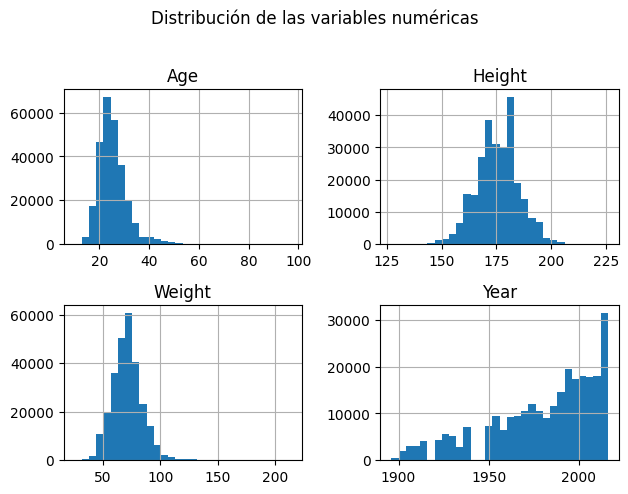

In [95]:
# Histogramas
df[numericas].hist(bins=30)
plt.suptitle('Distribución de las variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

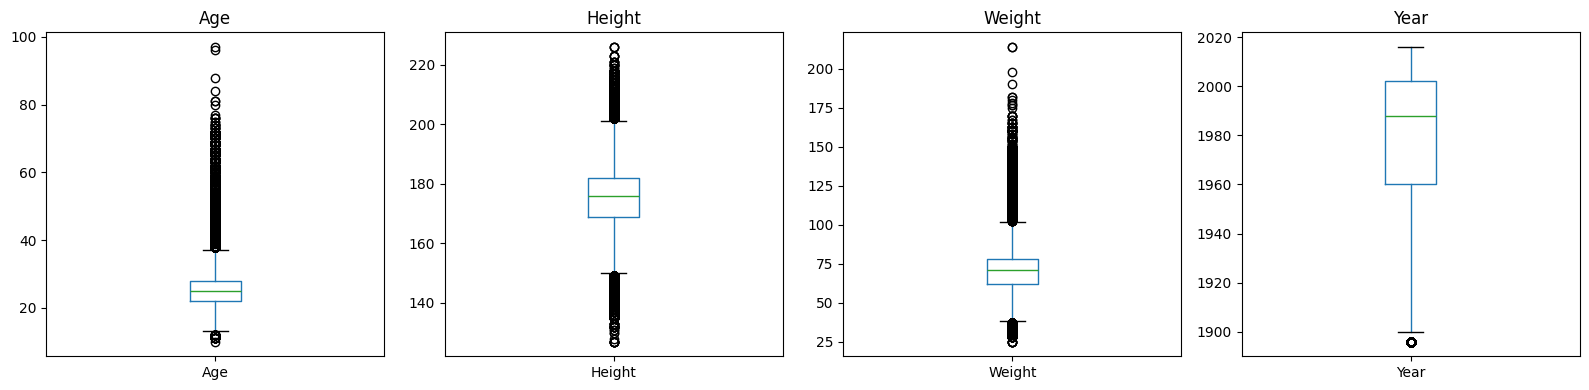

In [96]:
# Boxplots para ver valores atípicos
fig, axes = plt.subplots(1, len(numericas), figsize=(16, 4))
for ax, var in zip(axes, numericas):
    df.boxplot(column=var, ax=ax, grid=False)
    ax.set_title(var)
plt.tight_layout()
plt.show()


# Análisis de las variables numéricas

- Age: No es normal, aunque su gráfica muestra una forma parecida
- Height: Visualmente se asemeja a la normalidad, pero sus valores intermedios le dan un comportamiento distinto.
- Weight: Tiene una forma gráfica bastante parecida a la normalidad.
- Year: Tiene una distribución atípica, con saltos de valores (no es continua).

## Outliers
- Age: Presencia importante de outliers en el extremo superior.
- Height: Pocos outliers, algunos casos extremos.
- Weight: Outliers claros en el extremo superior.
- Year: No aplica ya que de esta no se pueden sacar conclusiones útiles.

## Procesamiento por variable
- Age: Por la cantidad de outliers, RobustScaler
- Height: StandardScaler ya que no hay demasiados outliers.
- Year: Ya que son valores discretos, la mejor sería MinMaxScaler.

Haga análisis bivariados entre las variables de su dataset y la variable objetivo, e identifique que variables serían potencialmente buenas predictoras y cuales no.

Reporte sus resultados en una celda de texto.

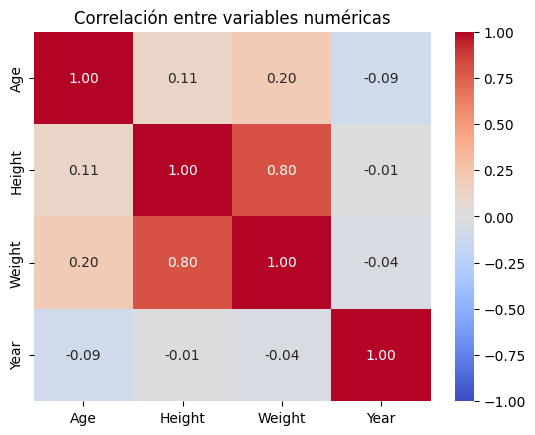

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Relaciones entre variables numéricas: matriz de correlación
corr = df[numericas].corr()
plt.figure()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.show()


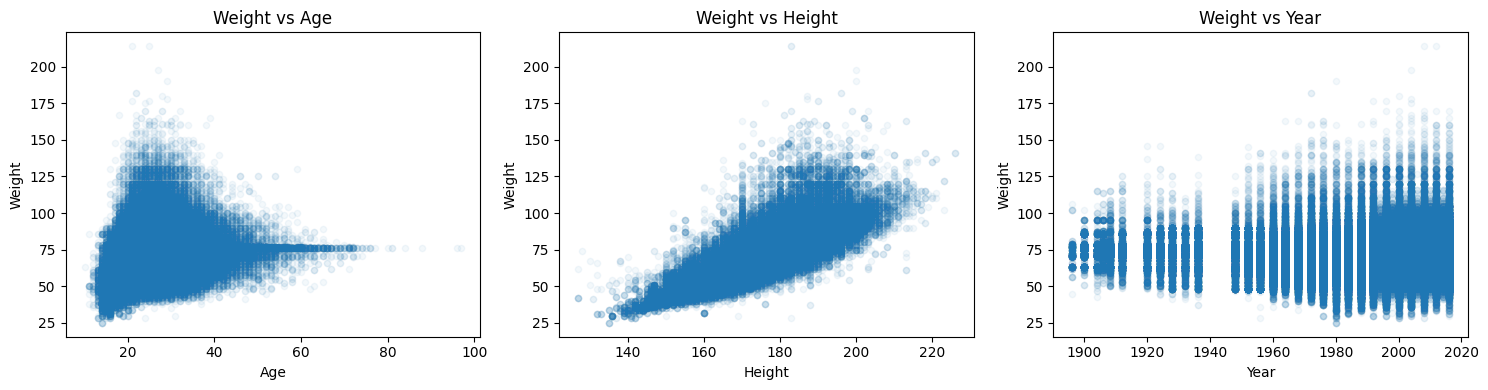

In [98]:
predictoras_numericas = [v for v in numericas if v != 'Weight'] # Se omite la objetivo
fig, axes = plt.subplots(1, len(predictoras_numericas), figsize=(15, 4))
for ax, var in zip(axes, predictoras_numericas):
    df.plot.scatter(x=var, y='Weight', alpha=0.05, ax=ax)
    ax.set_title(f'Weight vs {var}')
plt.tight_layout()
plt.show()


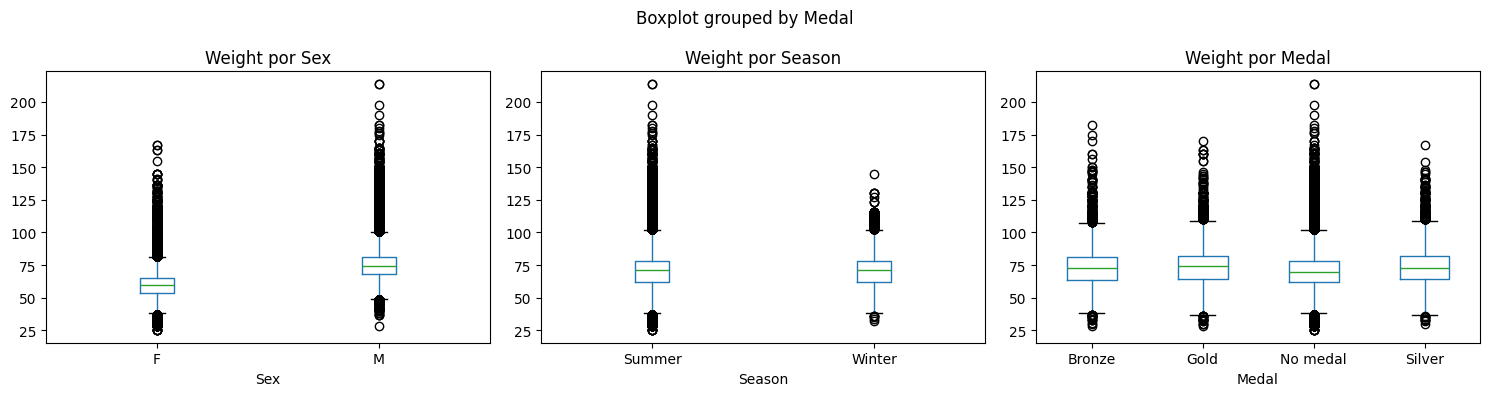

In [99]:
cat_bajas = ['Sex', 'Season', 'Medal']
fig, axes = plt.subplots(1, len(cat_bajas), figsize=(15, 4))
for ax, var in zip(axes, cat_bajas):
    df.boxplot(column='Weight', by=var, ax=ax, grid=False)
    ax.set_title(f'Weight por {var}')
    ax.set_xlabel(var)
plt.tight_layout()
plt.show()


<Figure size 1200x500 with 0 Axes>

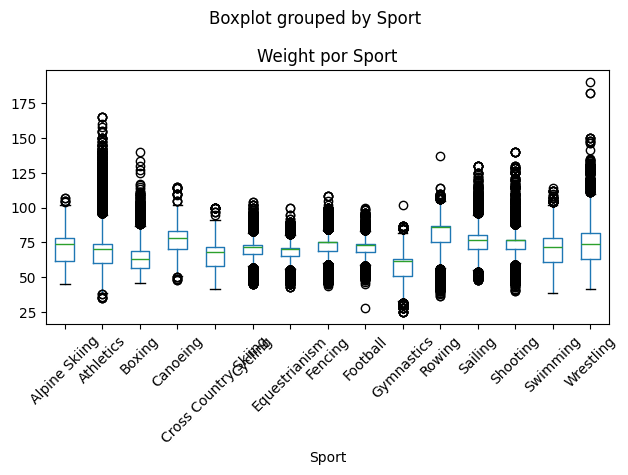

In [100]:
top_sports = df['Sport'].value_counts().head(15).index
plt.figure(figsize=(12, 5))
df[df['Sport'].isin(top_sports)].boxplot(column='Weight', by='Sport', grid=False, rot=45)
plt.title('Weight por Sport')
plt.tight_layout()
plt.show()

De aquí se concluye que:

- **Mejores predictoras**: `Height`, `Sex`, `Sport`.
- **Predictoras aceptables**: `Age`, `Season`, `NOC` (con procesamiento adecuado), `Medal`.
- **Descartar**: `Year` (correlación nula), `City` (aporta muy poco).

## Procesamiento de las características y entrenamiento del modelo

Cree el matriz de características $X$ con todos las variables no descartadas de su dataframe, menos la variable **Weight**, que será su variable objetivo $y$.

Particione los datos en subconjuntos de entrenamiento y prueba, en un relacion 80/20, usando `random_state=1`.

Para una primera versión de su modelo, seleccione 5 características a procesar que, de acuerdo con el análisis exploratorio realizado, parezcan ser buenas predictoras. Dentro de las 5 debe haber al menos una característica ordinal y dos nominales.

Empaquete las transformaciones que aplicará a estas características usando `ColumnTransformer`. Use el parámetro `remainder='drop'`para descartar las variables que no va a procesar.

Para el modelado va a usar un modelo de regresión logística. Cree un flujo de trabajo que integre el procesamiento y el modelado usando `Pipeline`.

Entrene el modelo y reporte los scores de entrenamiento y de prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression

# --- Matriz de características X y objetivo y ---
X = df.drop(columns=['Weight'])
y = df['Weight']

# --- Partición 80/20 con random_state=1 ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, random_state=1
)

print(f'Tamaño del conjunto de entrenamiento: {X_train.shape}')
print(f'Tamaño del conjunto de prueba: {X_test.shape}')


Tamaño del conjunto de entrenamiento: (215784, 10)
Tamaño del conjunto de prueba: (53947, 10)


In [102]:
ss = StandardScaler()                            # Para Height y Age
ohe_binary = OneHotEncoder(drop='if_binary',
                           sparse_output=False)  # Para Sex (binaria)
ohe_sport = OneHotEncoder(max_categories=15,
                          sparse_output=False,
                          handle_unknown='infrequent_if_exist')  # Para Sport
orden_medal = ['No medal', 'Bronze', 'Silver', 'Gold']
ore_medal = OrdinalEncoder(categories=[orden_medal], dtype='int')  # Para Medal

preprocessor = ColumnTransformer(
    transformers=[
        ('num',     ss,         ['Height', 'Age']),
        ('sex',     ohe_binary, ['Sex']),
        ('sport',   ohe_sport,  ['Sport']),
        ('medal',   ore_medal,  ['Medal']),
    ],
    remainder='drop'  # Descartamos el resto de columnas
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(), ['Height', 'Age']),
                                ('sex',
                                 OneHotEncoder(drop='if_binary',
                                               sparse_output=False),
                                 ['Sex']),
                                ('sport',
                                 OneHotEncoder(handle_unknown='infrequent_if_exist',
                                               max_categories=15,
                                               sparse_output=False),
                                 ['Sport']),
                                ('medal',
                                 OrdinalEncoder(categories=[['No medal',
                                                             'Bronze', 'Silver',
                                                             'Gold']],
                                                dtype='int'),
                                 ['Medal'])])

In [103]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Entrenamiento
pipeline.fit(X_train, y_train)

# Evaluación
score_train = pipeline.score(X_train, y_train)
score_test  = pipeline.score(X_test,  y_test)
print(f'R² en entrenamiento: {score_train:.4f}')
print(f'R² en prueba:        {score_test:.4f}')


R² en entrenamiento: 0.6911
R² en prueba:        0.6977


In [104]:
# Características REALES con las que se entrenó el modelo
# (las resultantes del ColumnTransformer, no las de entrada)
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
print(f'Número de características tras el procesamiento: {len(feature_names)}')
print()
print('Listado de características:')
for i, name in enumerate(feature_names):
    print(f'  {i + 1}. {name}')


Número de características tras el procesamiento: 19

Listado de características:
  1. num__Height
  2. num__Age
  3. sex__Sex_M
  4. sport__Sport_Alpine Skiing
  5. sport__Sport_Athletics
  6. sport__Sport_Canoeing
  7. sport__Sport_Cross Country Skiing
  8. sport__Sport_Cycling
  9. sport__Sport_Equestrianism
  10. sport__Sport_Fencing
  11. sport__Sport_Football
  12. sport__Sport_Gymnastics
  13. sport__Sport_Rowing
  14. sport__Sport_Sailing
  15. sport__Sport_Shooting
  16. sport__Sport_Swimming
  17. sport__Sport_Wrestling
  18. sport__Sport_infrequent_sklearn
  19. medal__Medal


Vuelva a entrenar el modelo, pero esta vez añada 2 características adicionales.

Reporte los scores de entrenamiento y de prueba del modelo reentrenado.

Reporte las características con las que **realmente** fue reentrenado el modelo, es decir, las resultantes del paso de procesamiento.

In [105]:
# Se añaden 2 características adicionales
# Elegidas: Season (nominal binaria) y NOC (nominal de alta cardinalidad)

ohe_season = OneHotEncoder(drop='if_binary',
                           sparse_output=False)  # Season (binaria)
ohe_noc    = OneHotEncoder(min_frequency=500,
                           sparse_output=False,
                           handle_unknown='infrequent_if_exist')  # NOC (alta cardinalidad)

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num',     ss,         ['Height', 'Age']),
        ('sex',     ohe_binary, ['Sex']),
        ('sport',   ohe_sport,  ['Sport']),
        ('medal',   ore_medal,  ['Medal']),
        ('season',  ohe_season, ['Season']),   # NUEVA
        ('noc',     ohe_noc,    ['NOC']),      # NUEVA
    ],
    remainder='drop'
)

pipeline_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('model', LinearRegression())
])

# Reentrenamiento
pipeline_v2.fit(X_train, y_train)

# Evaluación
score_train_v2 = pipeline_v2.score(X_train, y_train)
score_test_v2  = pipeline_v2.score(X_test,  y_test)
print(f'R² en entrenamiento (v2): {score_train_v2:.4f}')
print(f'R² en prueba (v2):        {score_test_v2:.4f}\n')
print(f'Mejora en test: +{score_test_v2 - score_test:.4f}')


R² en entrenamiento (v2): 0.6938
R² en prueba (v2):        0.7003

Mejora en test: +0.0026


In [106]:
# Características reales tras el procesamiento en el modelo v2
feature_names_v2 = pipeline_v2.named_steps['preprocessor'].get_feature_names_out()
print(f'Número de características tras el procesamiento: {len(feature_names_v2)}\n')
print('Listado de características:')
for i, name in enumerate(feature_names_v2):
    print(f'  {i+1:2d}. {name}')


Número de características tras el procesamiento: 90

Listado de características:
   1. num__Height
   2. num__Age
   3. sex__Sex_M
   4. sport__Sport_Alpine Skiing
   5. sport__Sport_Athletics
   6. sport__Sport_Canoeing
   7. sport__Sport_Cross Country Skiing
   8. sport__Sport_Cycling
   9. sport__Sport_Equestrianism
  10. sport__Sport_Fencing
  11. sport__Sport_Football
  12. sport__Sport_Gymnastics
  13. sport__Sport_Rowing
  14. sport__Sport_Sailing
  15. sport__Sport_Shooting
  16. sport__Sport_Swimming
  17. sport__Sport_Wrestling
  18. sport__Sport_infrequent_sklearn
  19. medal__Medal
  20. season__Season_Winter
  21. noc__NOC_ARG
  22. noc__NOC_AUS
  23. noc__NOC_AUT
  24. noc__NOC_BEL
  25. noc__NOC_BLR
  26. noc__NOC_BRA
  27. noc__NOC_BUL
  28. noc__NOC_CAN
  29. noc__NOC_CHI
  30. noc__NOC_CHN
  31. noc__NOC_COL
  32. noc__NOC_CRO
  33. noc__NOC_CUB
  34. noc__NOC_CZE
  35. noc__NOC_DEN
  36. noc__NOC_EGY
  37. noc__NOC_ESP
  38. noc__NOC_EST
  39. noc__NOC_EUN
  40. noc_